# Preparación del entorno y carga de librerías

En esta sección se instalan e importan las librerías necesarias para el desarrollo del sistema de detección de bots.

Se utilizan librerías de análisis de datos como `pandas` y `numpy`, herramientas de visualización como `matplotlib` y `seaborn`, y modelos de aprendizaje automático de `scikit-learn`.

Además, se incluye `joblib` para la persistencia de modelos, permitiendo su posterior uso en entornos de producción.

In [ ]:
# =========================
# Instalación (si hace falta)
# =========================
!pip install -q scikit-learn xgboost joblib

# =========================
# Librerías
# =========================
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import StandardScaler

# Carga y estructuración del dataset (JSON)

Se carga el dataset en formato JSON que contiene registros de tráfico web.

Dado que el archivo original está estructurado como un diccionario, se convierte en una lista de registros para facilitar su manipulación.

Posteriormente, se transforma en un DataFrame de pandas, lo que permite aplicar operaciones de análisis y procesamiento de datos de manera eficiente.

In [ ]:
# =========================
# Cargar dataset
# =========================

with open("/content/drive/MyDrive/TFG_Backend_WebBotDetection/dataset/public_v2.json", "r") as f:
    data = json.load(f)

# Convertir dict gigante -> lista
records = list(data.values())

df = pd.DataFrame(records)

print("Shape:", df.shape)
df.head()

Shape: (4091155, 9)


,referrer,request,method,resource,bytes,response,ip,useragent,timestamp
0,http://search.lib.auth.gr/Record/68b03dbc211ec...,search.lib.auth.gr:80 66.249.34457 - - [01/Mar...,GET,/AJAX/d780f3cf8bf4e286eb6dec2f372f6d7870b6b08c...,491,200,66.249.34457,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,2018-02-28T22:00:01.000Z
1,-,search.lib.auth.gr:80 202.180.35500 - - [01/Ma...,GET,/Record/6e324aa5c04e928302b74721397b29ec63c506...,23282,200,202.180.35500,ICC-Crawler/2.0 (Mozilla-compatible; ; http://...,2018-02-28T22:00:01.000Z
2,http://search.lib.auth.gr/Record/a85fc3e1e9e2b...,search.lib.auth.gr:80 87.202.48402 - - [01/Mar...,GET,/Record/cf5286a234e3de2754866895d2f43dc73a1d0e...,8952,200,87.202.48402,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:5...,2018-02-28T22:00:03.000Z
3,http://search.lib.auth.gr/Record/cf5286a234e3d...,search.lib.auth.gr:80 87.202.48402 - - [01/Mar...,GET,/AJAX/75300e1d0c73156110c4668f681cfa79566dfb26...,490,200,87.202.48402,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:5...,2018-02-28T22:00:04.000Z
4,http://search.lib.auth.gr/Record/cf5286a234e3d...,search.lib.auth.gr:80 87.202.48402 - - [01/Mar...,GET,/Cover/Show?e2daf94236f6b2fca94024206589bfaf07...,677,200,87.202.48402,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:5...,2018-02-28T22:00:04.000Z


# Limpieza y preprocesamiento inicial

Se realiza una limpieza básica del dataset para garantizar la calidad de los datos.

Se convierten variables como `timestamp`, `response` y `bytes` a tipos adecuados (fecha y numéricos), gestionando posibles errores mediante coerción.

Además, se eliminan registros incompletos en variables críticas como la dirección IP y el timestamp, asegurando la consistencia del análisis posterior.

In [ ]:
# Convertir tipos
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["response"] = pd.to_numeric(df["response"], errors="coerce")
df["bytes"] = pd.to_numeric(df["bytes"], errors="coerce")

df = df.dropna(subset=["ip", "timestamp"])

print("Registros tras limpieza:", df.shape)

Registros tras limpieza: (4091155, 9)


# Generación de la variable objetivo (etiquetado automático)

Se crea la variable objetivo `is_bot` mediante un enfoque heurístico basado en el análisis del campo `useragent`.

Se identifican patrones comunes asociados a bots (como "crawler", "spider" o "googlebot") y se asigna una etiqueta binaria:
- 1 → Bot
- 0 → Usuario humano

Este enfoque permite generar etiquetas sin necesidad de un dataset previamente anotado.

In [ ]:
bot_keywords = [
    "bot", "crawler", "spider",
    "googlebot", "bingbot",
    "yandex", "baiduspider",
    "facebookexternalhit",
    "archive", "bubing", "icc-crawler"
]

df["is_bot"] = df["useragent"].str.lower().apply(
    lambda x: 1 if any(k in str(x) for k in bot_keywords) else 0
)

df["is_bot"].value_counts()

,count
is_bot,
0,3689526
1,401629


# Ingeniería de características a nivel de IP

Se construyen nuevas variables agregadas que capturan el comportamiento de cada dirección IP.

Entre las características generadas destacan:
- Número de peticiones por IP
- Tiempo medio entre peticiones
- Ratio de errores HTTP
- Diversidad de recursos accedidos

Estas variables permiten modelar patrones de comportamiento, clave para diferenciar entre usuarios humanos y bots.

In [ ]:
df = df.sort_values(["ip", "timestamp"])

1. Requests por IP

In [ ]:
ip_counts = df.groupby("ip").size().reset_index(name="requests_per_ip")
df = df.merge(ip_counts, on="ip")

2. Tiempo entre requests

In [ ]:
df["time_diff"] = df.groupby("ip")["timestamp"].diff().dt.total_seconds()
df["time_diff"] = df["time_diff"].fillna(0)

avg_time_diff = df.groupby("ip")["time_diff"].mean().reset_index(name="avg_time_diff")
df = df.merge(avg_time_diff, on="ip")

3. Ratio de errores

In [ ]:
df["is_error"] = df["response"].between(400, 599).astype(int)

error_rate = df.groupby("ip")["is_error"].mean().reset_index(name="error_rate")
df = df.merge(error_rate, on="ip")

4. Diversidad de recursos

In [ ]:
resource_div = df.groupby("ip")["resource"].nunique().reset_index(name="unique_resources")
df = df.merge(resource_div, on="ip")

# Construcción del dataset final por usuario

Se agrupan los datos a nivel de dirección IP, generando un único registro por usuario.

Se combinan las características previamente calculadas y se asigna la etiqueta final (`is_bot`), lo que permite transformar el problema en un modelo de clasificación supervisada.

In [ ]:
df_ip = df.groupby("ip").agg({
    "requests_per_ip": "first",
    "avg_time_diff": "first",
    "error_rate": "first",
    "unique_resources": "first",
    "is_bot": "max"
}).reset_index()

df_ip.head()

,ip,requests_per_ip,avg_time_diff,error_rate,unique_resources,is_bot
0,1.239.59134,1,0.000000,0.0,1,0
1,1.31.39433,1,0.000000,0.0,1,0
2,1.62.42586,1,0.000000,1.0,1,0
3,101.226.30020,11,0.818182,0.0,11,0
4,101.226.41380,11,4.000000,0.0,11,0


# División del dataset en entrenamiento y prueba

Se divide el conjunto de datos en subconjuntos de entrenamiento y prueba para evaluar el modelo de forma objetiva.

Se mantiene la proporción de clases mediante `stratify`, lo cual es fundamental para evitar sesgos en datasets desbalanceados.

In [ ]:
X = df_ip.drop(["ip", "is_bot"], axis=1)
y = df_ip["is_bot"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Entrenamiento del modelo Random Forest

Se entrena un modelo Random Forest, un algoritmo de aprendizaje supervisado basado en múltiples árboles de decisión.

Este modelo es robusto frente a ruido y permite capturar relaciones no lineales entre variables.

Se configuran parámetros como el número de árboles (`n_estimators`) y la profundidad máxima (`max_depth`) para controlar el rendimiento y evitar sobreajuste.



In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=200, n_jobs=-1,
                       random_state=42)

# Evaluación del modelo

Se evalúa el rendimiento del modelo mediante diferentes métricas:
- Matriz de confusión
- Precision, Recall y F1-score
- ROC-AUC

Estas métricas permiten analizar tanto la capacidad de detección de bots como el equilibrio entre falsos positivos y negativos.

In [ ]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))



[[4904   58]
 [ 197  235]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      4962
           1       0.80      0.54      0.65       432

    accuracy                           0.95      5394
   macro avg       0.88      0.77      0.81      5394
weighted avg       0.95      0.95      0.95      5394

ROC-AUC: 0.9530288992640364


# Curva ROC

Se representa la curva ROC, que muestra la relación entre la tasa de verdaderos positivos (TPR) y falsos positivos (FPR).

El área bajo la curva (AUC) permite evaluar la capacidad discriminativa del modelo independientemente del threshold.

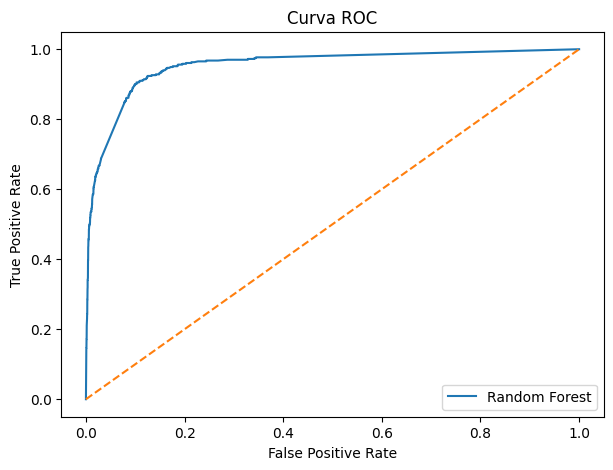

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

#Curva Precision-Recall

Se representa la curva Precision-Recall, especialmente relevante en problemas desbalanceados.

Esta curva permite analizar el compromiso entre precisión y recall, proporcionando una visión más realista del rendimiento del modelo en detección de bots.

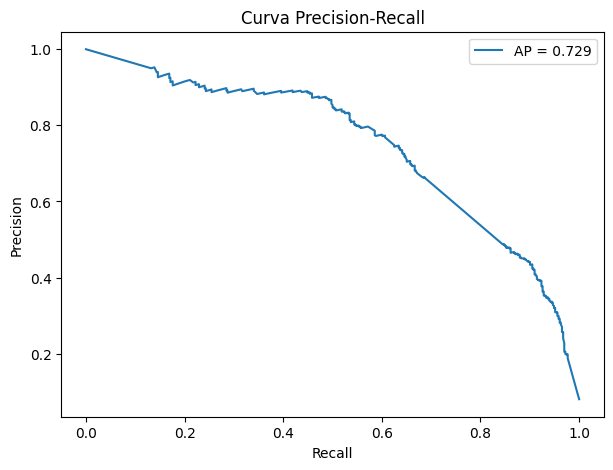

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.show()

# Análisis de importancia de características

Se analiza la importancia de cada variable en el modelo Random Forest.

Este análisis permite identificar qué factores influyen más en la detección de bots, aportando interpretabilidad al modelo.

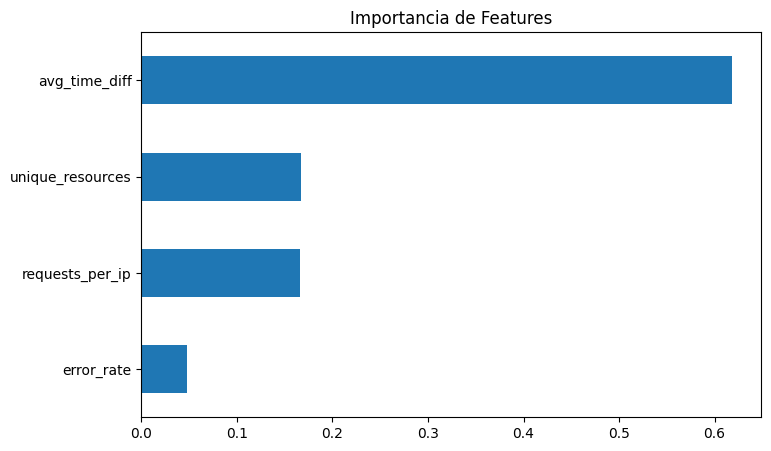

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Importancia de Features")
plt.show()

# Persistencia del modelo

Se guarda el modelo entrenado utilizando `joblib`, lo que permite reutilizarlo en sistemas de producción sin necesidad de reentrenamiento.

In [ ]:
joblib.dump(rf, "web_bot_detector.pkl")

print("Modelo guardado correctamente")

Modelo guardado correctamente


# Ajuste del umbral de decisión

Se evalúan distintos valores de threshold para convertir probabilidades en clases binarias.

Este proceso permite optimizar métricas como el F1-score, ajustando el equilibrio entre precisión y recall según las necesidades del sistema.

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_pred_temp = (y_proba >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_temp))


Threshold: 0.1
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      4962
           1       0.42      0.91      0.57       432

    accuracy                           0.89      5394
   macro avg       0.71      0.90      0.76      5394
weighted avg       0.95      0.89      0.91      5394


Threshold: 0.15000000000000002
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      4962
           1       0.46      0.88      0.60       432

    accuracy                           0.91      5394
   macro avg       0.72      0.89      0.77      5394
weighted avg       0.95      0.91      0.92      5394


Threshold: 0.20000000000000004
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      4962
           1       0.48      0.85      0.61       432

    accuracy                           0.91      5394
   macro avg       0.73      0.89      0.78     

# Análisis visual del threshold óptimo

Se representa la evolución del F1-score en función del threshold.

Esto permite identificar de forma visual el punto óptimo de decisión y justificar su elección en el contexto del problema.

In [ ]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_temp = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print("Mejor threshold:", best_threshold)
print("Mejor F1:", best_f1)

Mejor threshold: 0.37000000000000005
Mejor F1: 0.685


#Guardar el threshold óptimo correctamente

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_temp = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print("Mejor threshold:", best_threshold)
print("Mejor F1:", best_f1)

Mejor threshold: 0.37000000000000005
Mejor F1: 0.685


# Integración en backend mediante API

Se implementa una API utilizando FastAPI para desplegar el modelo en producción.

El sistema recibe características de entrada, calcula la probabilidad de que un usuario sea un bot y devuelve:
- Probabilidad
- Clasificación final
- Threshold utilizado

Esto permite integrar el modelo en aplicaciones reales.

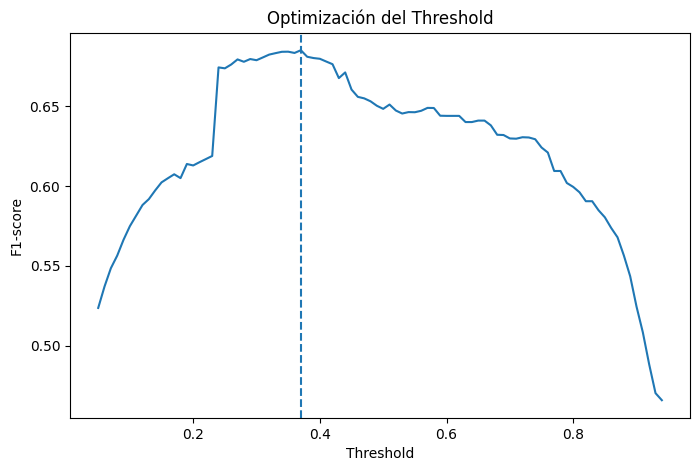

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, linestyle='--')
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Optimización del Threshold")
plt.show()

#3. Guardar modelo + threshold juntos

In [ ]:
import joblib

model_package = {
    "model": rf,
    "threshold": float(best_threshold)
}

joblib.dump(model_package, "web_bot_detector2.pkl")
print("Modelo y threshold guardados correctamente")

Modelo y threshold guardados correctamente


# Modelo XGBoost

Se implementa el algoritmo XGBoost, un modelo de boosting que mejora el rendimiento mediante el aprendizaje secuencial de árboles.

Este modelo suele ofrecer mejores resultados en problemas de clasificación complejos.

In [ ]:
import joblib
import numpy as np
from fastapi import FastAPI

app = FastAPI()

# Cargar modelo
package = joblib.load("xgboost.pkl")
model = package["model"]
threshold = package["threshold_f1"] # Using the F1-optimized threshold

@app.post("/predict")
def predict(features: dict):

    X = np.array([[
        features["requests_per_ip"],
        features["avg_time_diff"],
        features["error_rate"],
        features["unique_resources"]
    ]])

    probability = model.predict_proba(X)[0][1]
    classification = int(probability >= threshold)

    return {
        "bot_probability": float(probability),
        "classification": classification,
        "threshold_used": threshold
    }

    print(bot_probability)
    print(classification)
    print(threshold_used)

# Comparación entre Random Forest y XGBoost

Se comparan ambos modelos utilizando métricas como F1-score y ROC-AUC.

Esto permite evaluar qué enfoque resulta más adecuado para el problema de detección de bots.

In [ ]:
!pip install xgboost

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_proba_xgb = xgb.predict_proba(X_test)[:,1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

XGBoost ROC-AUC: 0.9606570118082614


#Comparativa formal RF vs XGB

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# Random Forest
y_pred_rf = (y_proba >= best_threshold).astype(int)

# XGBoost (threshold 0.5 provisional)
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\n=== XGBOOST ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      4962
           1       0.74      0.63      0.69       432

    accuracy                           0.95      5394
   macro avg       0.86      0.81      0.83      5394
weighted avg       0.95      0.95      0.95      5394

ROC-AUC: 0.9530288992640364

=== XGBOOST ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4962
           1       0.80      0.59      0.68       432

    accuracy                           0.96      5394
   macro avg       0.88      0.79      0.83      5394
weighted avg       0.95      0.96      0.95      5394

ROC-AUC: 0.9606570118082614


#----------------------------------------------------------------------
#**Optimización del threshold en XGBoost**

Se realiza un ajuste del threshold en XGBoost para maximizar el F1-score, siguiendo el mismo enfoque aplicado anteriormente.

Esto permite mejorar el rendimiento del modelo sin modificar su estructura interna.

#--------------------------------------------------------------------

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores_xgb = []

for t in thresholds:
    y_pred_temp = (y_proba_xgb >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    f1_scores_xgb.append(f1)

best_threshold_xgb = thresholds[np.argmax(f1_scores_xgb)]
best_f1_xgb = max(f1_scores_xgb)

print("Mejor threshold XGBoost:", best_threshold_xgb)
print("Mejor F1 XGBoost:", best_f1_xgb)

Mejor threshold XGBoost: 0.4100000000000001
Mejor F1 XGBoost: 0.6869455006337135


#Gráfica F1 vs Threshold (XGB)

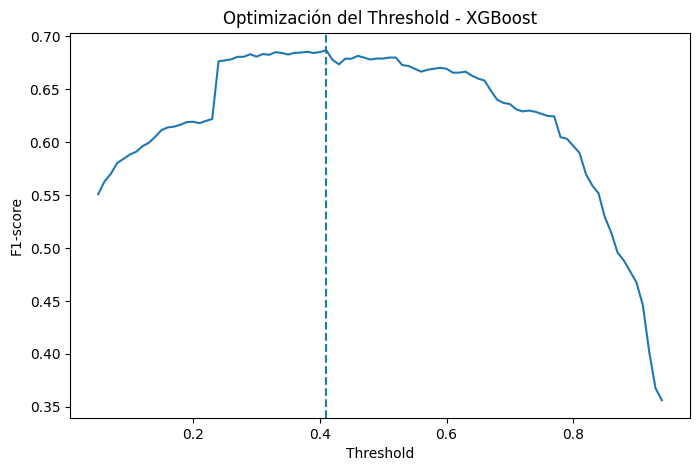

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores_xgb)
plt.axvline(best_threshold_xgb, linestyle='--')
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Optimización del Threshold - XGBoost")
plt.show()

#Evaluar XGBoost con threshold optimizado

In [ ]:
from sklearn.metrics import classification_report

y_pred_xgb_opt = (y_proba_xgb >= best_threshold_xgb).astype(int)

print("=== XGBOOST OPTIMIZADO ===")
print(classification_report(y_test, y_pred_xgb_opt))

=== XGBOOST OPTIMIZADO ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4962
           1       0.76      0.63      0.69       432

    accuracy                           0.95      5394
   macro avg       0.86      0.80      0.83      5394
weighted avg       0.95      0.95      0.95      5394



# **Evaluación basada en coste**

Se introduce una métrica de coste que penaliza los errores del modelo:
- Falsos negativos → mayor coste
- Falsos positivos → menor coste

Este enfoque permite alinear el modelo con objetivos reales de negocio.

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

C_FN = 10
C_FP = 1

costs = []

for t in thresholds:
    y_pred_temp = (y_proba_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    cost = C_FN * fn + C_FP * fp
    costs.append(cost)

best_cost_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)

print("Threshold óptimo por coste:", best_cost_threshold)
print("Coste mínimo:", min_cost)

Threshold óptimo por coste: 0.08000000000000002
Coste mínimo: 874


#Gráfica de coste

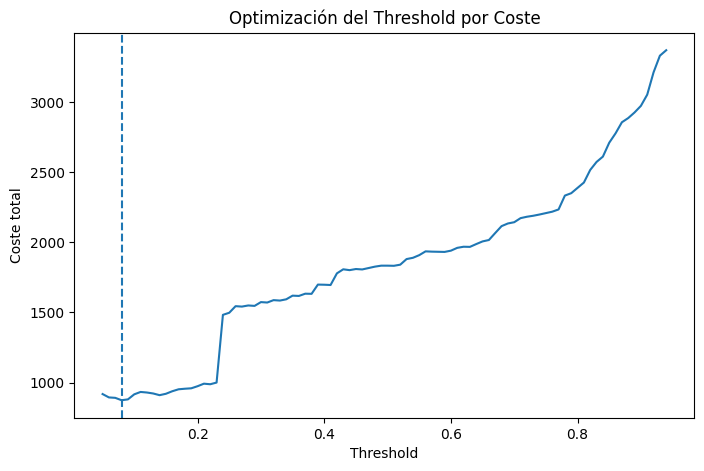

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(thresholds, costs)
plt.axvline(best_cost_threshold, linestyle='--')
plt.xlabel("Threshold")
plt.ylabel("Coste total")
plt.title("Optimización del Threshold por Coste")
plt.show()

# Interpretabilidad del modelo con SHAP

Se utiliza SHAP (SHapley Additive exPlanations) para interpretar el comportamiento del modelo.

Esta técnica permite entender cómo cada variable contribuye a la predicción, tanto a nivel global como individual.

Esto es especialmente importante en sistemas críticos donde la explicabilidad es clave.

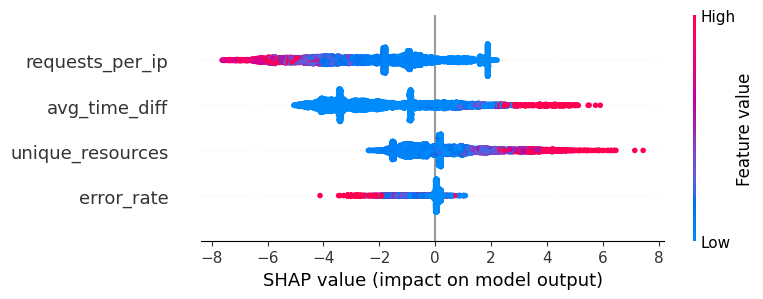

In [ ]:
!pip install shap

import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

#**Definición del modelo final**


Se selecciona el modelo XGBoost como modelo definitivo, junto con dos thresholds:
- Threshold optimizado por F1-score
- Threshold optimizado por coste

Esto permite adaptar el sistema según diferentes objetivos operativos.

In [ ]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

C_FN = 10
C_FP = 1

precision_list = []
recall_list = []
cost_list = []

for t in thresholds:
    y_pred_temp = (y_proba_xgb >= t).astype(int)

    precision_list.append(precision_score(y_test, y_pred_temp))
    recall_list.append(recall_score(y_test, y_pred_temp))

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
    cost = C_FN * fn + C_FP * fp
    cost_list.append(cost)

plt.figure(figsize=(10,6))

plt.plot(thresholds, recall_list, label="Recall")
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, cost_list, label="Coste")

plt.axvline(0.41, linestyle='--', label="Threshold F1")
plt.axvline(0.08, linestyle='--', label="Threshold Coste")

plt.xlabel("Threshold")
plt.legend()
plt.title("Comparativa Recall, Precision y Coste")
plt.show()

#Análisis SHAP por instancia individual

In [ ]:
import shap
shap.initjs()

index = 5  # usuario concreto
shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_test.iloc[index]
)

#**MODELO FINAL OFICIAL**

- Modelo: **XGBoost**

- Threshold balanceado: 0.41

- Threshold seguridad: 0.08


classification=1ifP(bot∣X)>=thresholdelse0

In [ ]:
#------------------------------------------------
# Crear paquete final de producción
#------------------------------------------------

import joblib

model_package = {
    "model": xgb,
    "threshold_f1": 0.41,
    "threshold_cost": 0.08,
    "features": [
        "requests_per_ip",
        "avg_time_diff",
        "unique_resources",
        "error_rate"
    ]
}

joblib.dump(model_package, "xgboost.pkl")



print("Modelo final guardado correctamente.")

Modelo final guardado correctamente.


In [ ]:

from sklearn.metrics import confusion_matrix

C_FN = 10
C_FP = 1

costs_rf = []

for t in thresholds:
    y_pred_temp = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    cost = C_FN * fn + C_FP * fp
    costs_rf.append(cost)

best_cost_threshold_rf = thresholds[np.argmin(costs_rf)]
min_cost_rf = min(costs_rf)

print("RF - Threshold óptimo por coste:", best_cost_threshold_rf)
print("RF - Coste mínimo:", min_cost_rf)

RF - Threshold óptimo por coste: 0.11000000000000001
RF - Coste mínimo: 932


#Guardar RandomForest como modelo de producción real

In [ ]:
rf_package = {
    "model": rf,
    "threshold_f1": float(best_threshold),
    "threshold_cost": float(best_cost_threshold_rf),
    "features": [
        "requests_per_ip",
        "avg_time_diff",
        "unique_resources",
        "error_rate"
    ]
}

joblib.dump(rf_package, "random_forest.pkl")

print("Random Forest guardado correctamente.")

Random Forest guardado correctamente.


#**Preparación del modelo para producción**

Se crea un paquete final que incluye:
- Modelo entrenado
- Thresholds optimizados
- Lista de variables de entrada

Este paquete permite desplegar el sistema en producción de forma eficiente y reutilizable.

In [ ]:
X.columns.tolist()

['requests_per_ip', 'avg_time_diff', 'error_rate', 'unique_resources']

In [ ]:
model.get_booster().feature_names

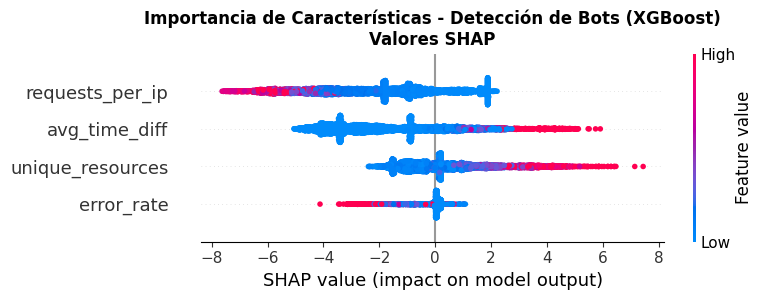

In [ ]:
# 7.15 Análisis de Interpretabilidad con SHAP
import shap
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
import numpy as np
import joblib

# Load the model package
model_package = joblib.load("/content/xgboost.pkl")
loaded_xgb_model = model_package["model"]

# Get feature names from the original DataFrame X
feature_names = X.columns.tolist()

# Crear explicador optimizado para XGBoost (árboles)
explainer = shap.TreeExplainer(loaded_xgb_model)
shap_values = explainer.shap_values(X_test)

# Gráfico de resumen beeswarm (Ilustración 24)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  show=False,
                  max_display=4)
plt.title("Importancia de Características - Detección de Bots (XGBoost)\nValores SHAP", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bots.png', dpi=300, bbox_inches='tight')
plt.show()

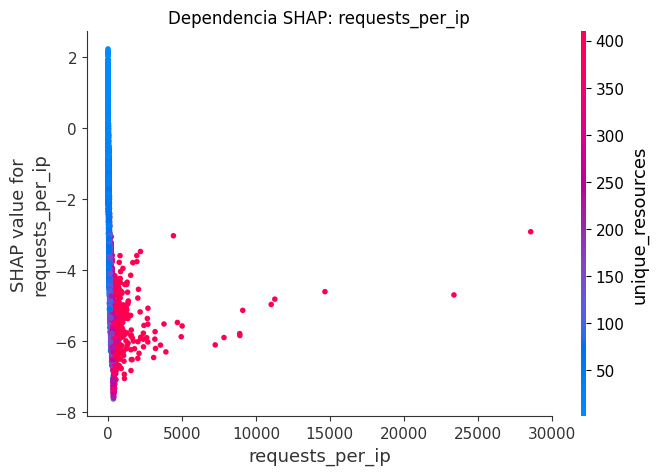

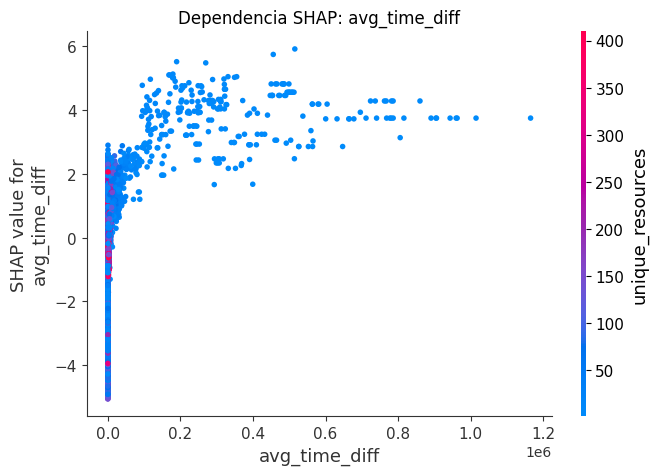

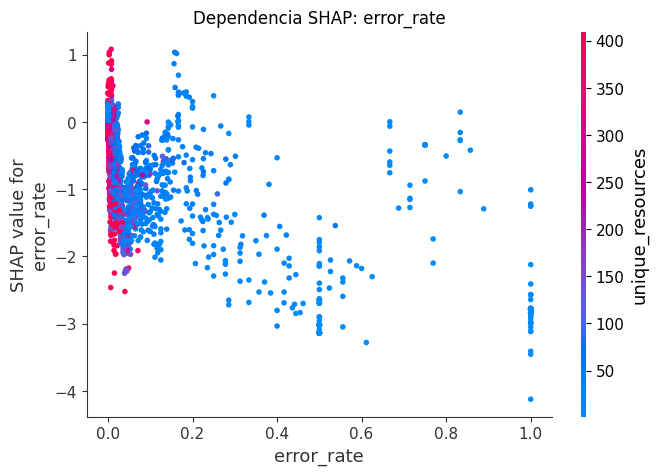

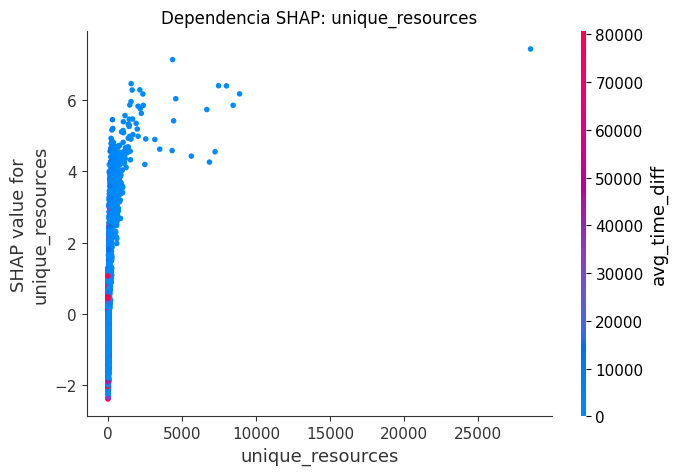

In [ ]:
# Ilustración 25: SHAP por característica individual
for i, feature in enumerate(feature_names):
    shap.dependence_plot(feature, shap_values, X_test,
                        feature_names=feature_names,
                        show=False)
    plt.title(f"Dependencia SHAP: {feature}")
    plt.savefig(f'shap_{feature}.png', dpi=300, bbox_inches='tight')
    plt.show()
